In [25]:
# ==========================================================
# 1. Imports
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")


In [26]:
# ==========================================================
# 2. Load Dataset
# ==========================================================

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "Dataset" / "cleaned_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9551, 20)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),1,0,0,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),1,0,0,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),1,0,0,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),0,0,0,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),1,0,0,4,4.8,Dark Green,Excellent,229


In [27]:
# ==========================================================
# 3. Remove Invalid Ratings
# ==========================================================

df = df[df["Aggregate rating"] > 0].copy()

print("Shape after removing zero ratings:", df.shape)

Shape after removing zero ratings: (7403, 20)


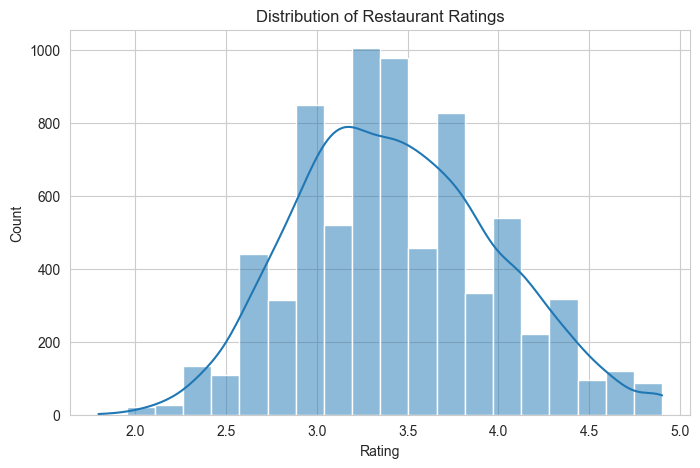

Insight:
Most restaurants fall between ratings 3.0 and 4.5 indicating moderate to high satisfaction.


In [28]:
# ==========================================================
# 4. Rating Distribution
# ==========================================================

plt.figure(figsize=(8,5))
sns.histplot(df["Aggregate rating"], bins=20, kde=True)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

print("Insight:")
print("Most restaurants fall between ratings 3.0 and 4.5 indicating moderate to high satisfaction.")


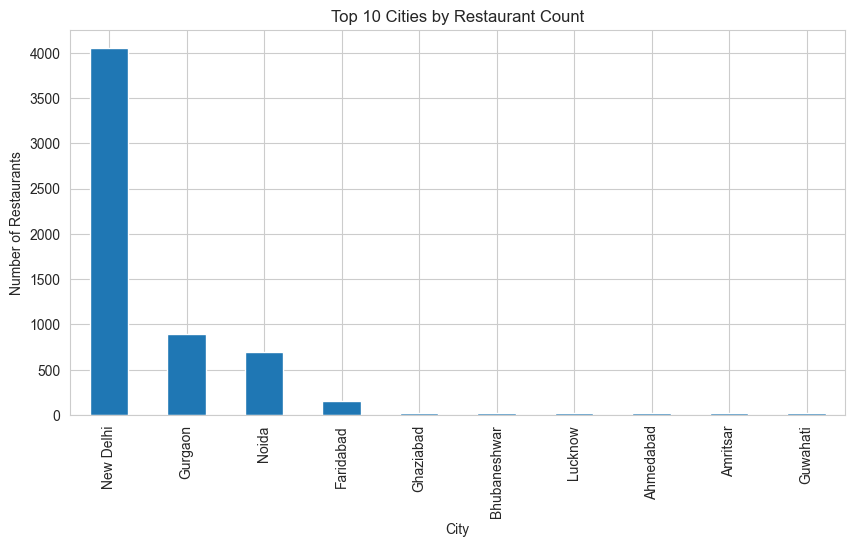

Insight:
Restaurant markets are highly concentrated in a few major cities.


In [29]:
# ==========================================================
# 5. Top Cities by Number of Restaurants
# ==========================================================

top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Restaurant Count")
plt.ylabel("Number of Restaurants")
plt.xlabel("City")

plt.show()

print("Insight:")
print("Restaurant markets are highly concentrated in a few major cities.")

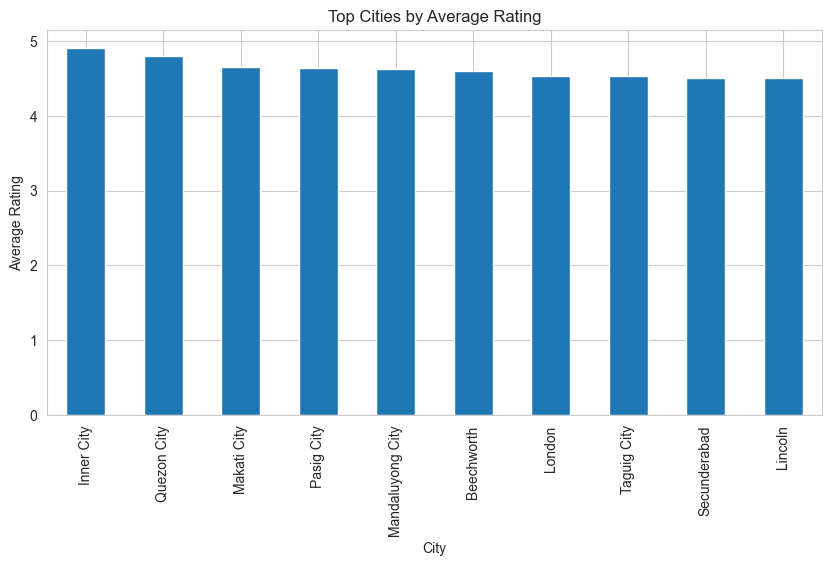

Insight:
Some cities consistently show higher satisfaction levels.


In [30]:
# ==========================================================
# 6. Average Rating by City
# ==========================================================

city_rating = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
city_rating.plot(kind="bar")

plt.title("Top Cities by Average Rating")
plt.ylabel("Average Rating")

plt.show()

print("Insight:")
print("Some cities consistently show higher satisfaction levels.")

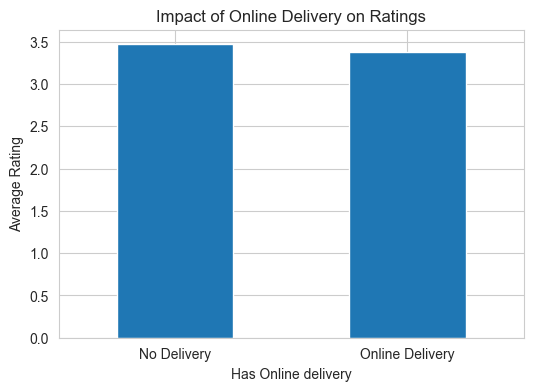

Insight:
Restaurants offering online delivery tend to receive slightly higher ratings.


In [31]:
# ==========================================================
# 7. Impact of Online Delivery
# ==========================================================

delivery_rating = df.groupby("Has Online delivery")["Aggregate rating"].mean()

plt.figure(figsize=(6,4))
delivery_rating.plot(kind="bar")

plt.xticks([0,1], ["No Delivery", "Online Delivery"], rotation=0)
plt.ylabel("Average Rating")

plt.title("Impact of Online Delivery on Ratings")

plt.show()

print("Insight:")
print("Restaurants offering online delivery tend to receive slightly higher ratings.")


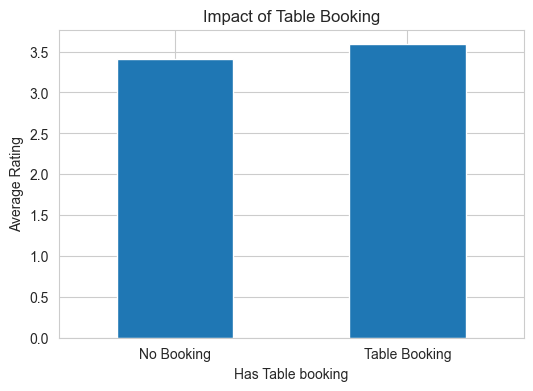

Insight:
Restaurants with table booking options tend to have better ratings.


In [32]:
# ==========================================================
# 8. Impact of Table Booking
# ==========================================================

booking_rating = df.groupby("Has Table booking")["Aggregate rating"].mean()

plt.figure(figsize=(6,4))
booking_rating.plot(kind="bar")

plt.xticks([0,1], ["No Booking", "Table Booking"], rotation=0)
plt.ylabel("Average Rating")

plt.title("Impact of Table Booking")

plt.show()

print("Insight:")
print("Restaurants with table booking options tend to have better ratings.")


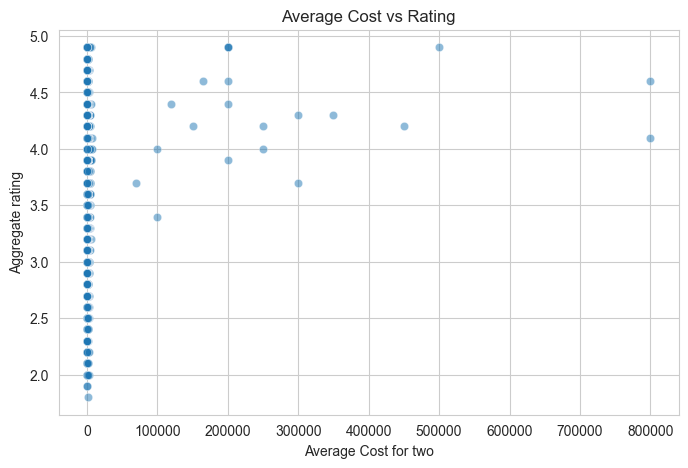

Insight:
Higher priced restaurants do not always guarantee higher ratings.


In [33]:
# ==========================================================
# 9. Cost vs Rating
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Average Cost for two"],
    y=df["Aggregate rating"],
    alpha=0.5
)

plt.title("Average Cost vs Rating")

plt.show()

print("Insight:")
print("Higher priced restaurants do not always guarantee higher ratings.")


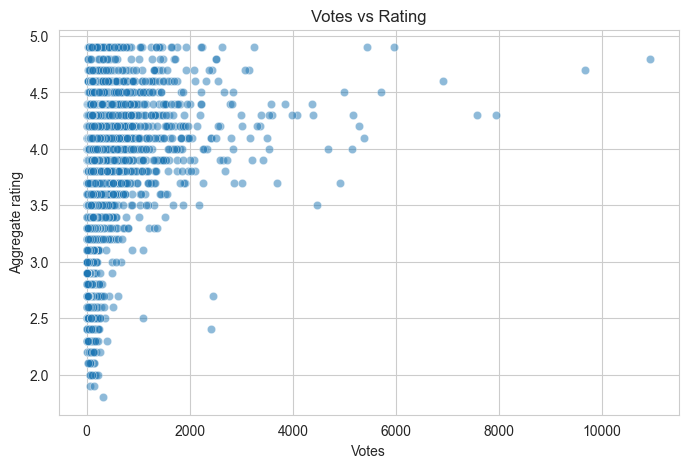

Insight:
Highly rated restaurants usually have more votes indicating popularity.


In [34]:
# ==========================================================
# 10. Votes vs Rating
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Votes"],
    y=df["Aggregate rating"],
    alpha=0.5
)

plt.title("Votes vs Rating")

plt.show()

print("Insight:")
print("Highly rated restaurants usually have more votes indicating popularity.")


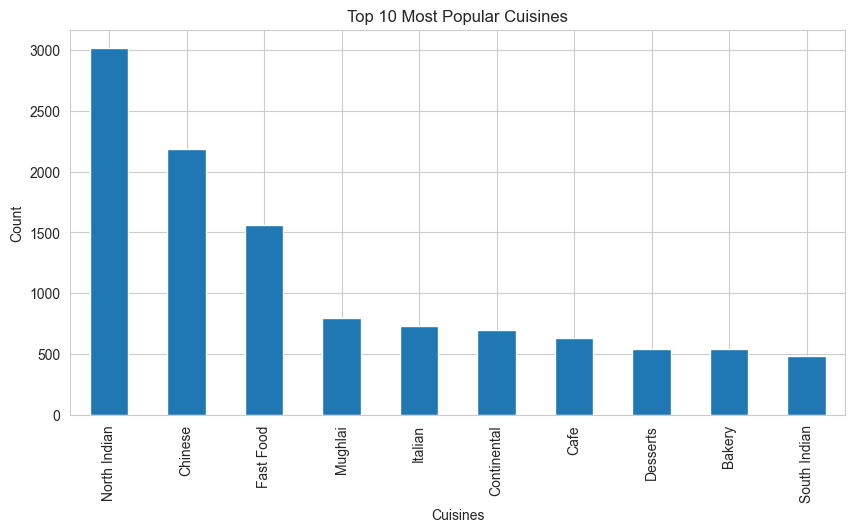

Insight:
A few cuisines dominate the restaurant market.


In [35]:

# ==========================================================
# 11. Top Cuisines
# ==========================================================

cuisine_series = df["Cuisines"].str.split(", ").explode()

top_cuisines = cuisine_series.value_counts().head(10)

plt.figure(figsize=(10,5))
top_cuisines.plot(kind="bar")

plt.title("Top 10 Most Popular Cuisines")

plt.ylabel("Count")

plt.show()

print("Insight:")
print("A few cuisines dominate the restaurant market.")


In [36]:
# ==========================================================
# 12. Final Business Recommendations
# ==========================================================

print("\n================ Business Recommendations ================\n")

print("1. Restaurants should prioritize online delivery services as they tend to receive higher ratings.")

print("2. Providing table booking improves customer experience and rating performance.")

print("3. Customer engagement (votes/reviews) strongly correlates with rating success.")

print("4. Location plays a major role — certain cities consistently perform better.")

print("5. Restaurants should focus on popular cuisines with high demand.")

print("6. Pricing alone does not guarantee higher ratings; service and experience matter more.")


================ Business Recommendations ================

1. Restaurants should prioritize online delivery services as they tend to receive higher ratings.
2. Providing table booking improves customer experience and rating performance.
3. Customer engagement (votes/reviews) strongly correlates with rating success.
4. Location plays a major role — certain cities consistently perform better.
5. Restaurants should focus on popular cuisines with high demand.
6. Pricing alone does not guarantee higher ratings; service and experience matter more.
